# Title: Feature Engineering
### Author: Kolbe Sussman

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import numpy as np

In [27]:
df = pd.read_csv("../data/processed/features_temporal.csv")


In [28]:
df.head()

,author_1,author_2,common_neighbors,jaccard,degree_diff,topic_overlap,dept_overlap,paper_diff,citation_diff,label
0,Bénédicte Stengel,Michelle Wong,13,0.541667,9,3,15,1,900,1
1,Katerina Kechris,Stephen I. Rennard,12,0.116505,89,3,12,15,3902,1
2,Annette Peters,Brian E. Cade,0,0.000000,18,4,57,9,5096,1
3,Sameer D. Saini,Scott Kaatz,0,0.000000,46,0,2,11,1793,1
4,Christina L. Gersch,Tianfeng Xu,0,0.000000,17,0,1,3,222,1


In [29]:
df.describe()

,common_neighbors,jaccard,degree_diff,topic_overlap,dept_overlap,paper_diff,citation_diff,label
count,601520.000000,601520.000000,601520.000000,601520.000000,601520.000000,601520.000000,601520.000000,601520.0
mean,2.805706,0.059548,50.608362,2.308871,12.785986,15.636892,4387.455991,0.5
std,6.621432,0.132339,87.660267,3.573718,40.098413,28.396411,9997.058253,0.5
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,6.000000,0.000000,1.000000,1.000000,287.000000,0.0
50%,1.000000,0.018182,18.000000,1.000000,2.000000,5.000000,1147.000000,0.5
75%,2.000000,0.050000,53.000000,3.000000,6.000000,17.000000,4174.000000,1.0
max,310.000000,1.000000,985.000000,88.000000,1140.000000,510.000000,148710.000000,1.0


In [30]:
feature_cols = [c for c in df.columns if c not in ['author_1','author_2','label']]

X = df[feature_cols]
y = df['label']

In [31]:
# Simple split is OK now (NO leakage anymore)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_pred_prob >= 0.5).astype(int)


In [35]:
auc = roc_auc_score(y_test, y_pred_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

AUC: 0.7467
Precision: 0.8145
Recall: 0.4846
F1 Score: 0.6077


In [38]:
def precision_at_k(y_true, y_scores, k):
    idx = np.argsort(y_scores)[::-1][:k]
    return y_true.iloc[idx].mean()

for k in [50, 100, 500, 1000]:
    p_at_k = precision_at_k(y_test.reset_index(drop=True),
                           pd.Series(y_pred_prob),
                           k)
    print(f"Precision@{k}: {p_at_k:.4f}")

Precision@50: 0.9800
Precision@100: 0.9900
Precision@500: 0.9960
Precision@1000: 0.9960


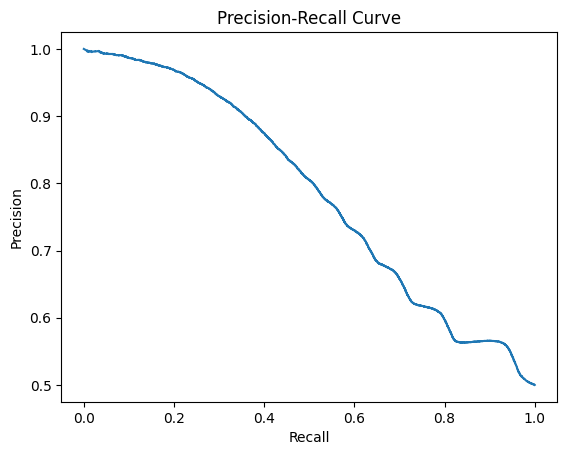

In [41]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [43]:
importances = rf.feature_importances_
feat_names = X.columns

imp_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure()
plt.barh(imp_df['feature'], imp_df['importance'])
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

ValueError: All arrays must be of the same length

In [44]:
df_test = df.iloc[y_test.index].copy()
df_test['score'] = y_pred_prob

top_preds = df_test.sort_values(by='score', ascending=False).head(20)

print(top_preds[['author_1','author_2','score','label']])

                    author_1             author_2  score  label
204707      Aki S. Havulinna             Wei Zhao    1.0      1
15083     Patricia A. Peyser          Xiuqing Guo    1.0      1
244981   L. Adrienne Cupples            Tōnu Esko    1.0      1
206425    Francis S. Collins     Jerome I. Rotter    1.0      1
287239          Anne Jackson          Xueling Sim    1.0      1
151372     Dorret I. Boomsma     John C. Chambers    1.0      1
57622            Daniel Levy     Lenore J. Launer    1.0      1
217862       Eric Boerwinkle   Rebecca D. Jackson    1.0      1
136368      Jerome I. Rotter  Lori L. Bonnycastle    1.0      1
104391        Laura J. Scott        Markku Laakso    1.0      1
151455   Gonçalo R. Abecasis      Sonja I. Berndt    1.0      1
240095          Anne Jackson     Johanna Kuusisto    1.0      1
58030    Braxton D. Mitchell  Gonçalo R. Abecasis    1.0      1
22733   Heather M. Stringham           Leif Groop    1.0      1
291124      Johanna Kuusisto        Torb

In [45]:
df_test = df.iloc[y_test.index].copy()
df_test['score'] = y_pred_prob

bottom_preds = df_test.sort_values(by='score', ascending=True).head(20)

print(bottom_preds[['author_1','author_2','score','label']])

                   author_1              author_2     score  label
560798            Guy Shani    Mason A. Carpenter  0.114473      0
458111   Caroline R. Dignan         Guangming Guo  0.114705      0
367884            S.L. Lacy              Wasin So  0.114744      0
536478  Gabriela Catterberg     Margaret Woodward  0.116316      0
335182      Gerald L. Clore       Hans‐J. Hippler  0.118313      0
513171    Jack Y. Edelstein     Robert J. Stimson  0.126309      0
365127          J. D. Hardy         J. S. Koehler  0.126545      0
465950           S.D. Booth  Saowapak Sotthivirat  0.126606      0
585581  Matthew A. Marriott         Peter K. Wung  0.133534      0
47118        Fábio C. Tucci     Matthias Kretzler  0.138338      1
557413      Emily C. Farrer       Linda Fleetwood  0.139377      0
88875             Hung Nien          Il Yong Chun  0.139395      1
312979            Mesou Lai                Yan Gu  0.139423      0
435963         James Dundas         Richard Uhlig  0.139787   